## Results Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# Reading data with results
model_files = {
    "xgboost": ("Results/xgboost_bayes.csv"),
    "decisiontree": ("Results/decisiontree_bayes.csv"),
    "knn": ("Results/knn_bayes.csv")
}

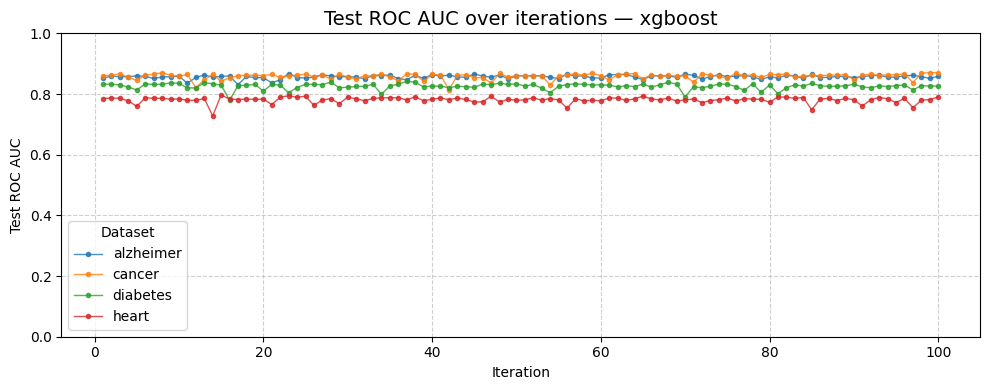

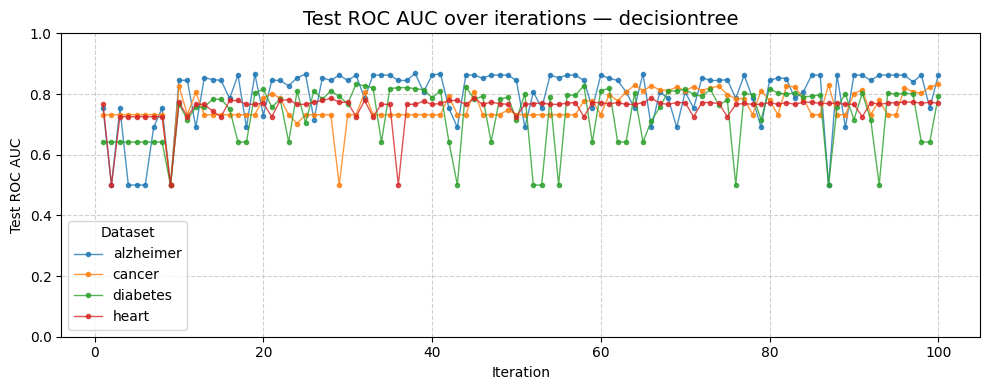

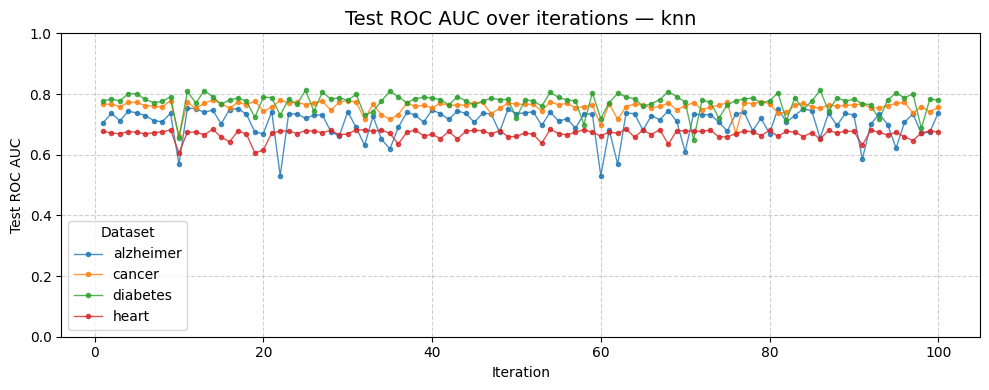

In [12]:
model_dfs = []
for model_name, file_path in model_files.items():
    df = pd.read_csv(file_path)
    df["model"] = model_name
    # Iterations are counted separately for each dataset and model
    df["iteration"] = df.groupby("dataset").cumcount() + 1
    model_dfs.append(df)

# All_df is a new dataframe with alll of our data
all_df = pd.concat(model_dfs, ignore_index=True)

models = all_df["model"].unique()

# Three plots showing 
for model_name in models:
    plt.figure(figsize=(10, 4))
    subset = all_df[all_df["model"] == model_name]

    for dataset_name, group in subset.groupby("dataset"):
        plt.plot(
            group["iteration"],
            group["test_roc_auc"],
            marker='o',
            linestyle='-',
            alpha=0.8,
            label=dataset_name,
            markersize=3,
            linewidth=1
        )

    plt.title(f"Test ROC AUC over iterations — {model_name}", fontsize=14)
    plt.xlabel("Iteration")
    plt.ylabel("Test ROC AUC")
    plt.ylim(0, 1)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Dataset")
    plt.tight_layout()
    plt.show()

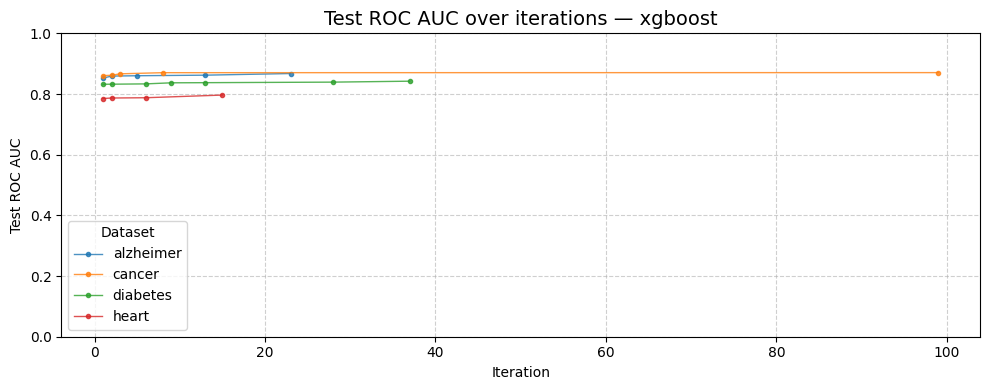

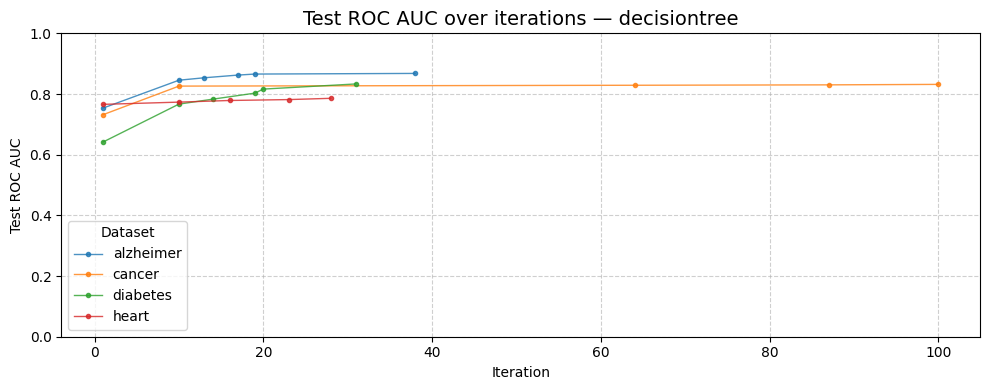

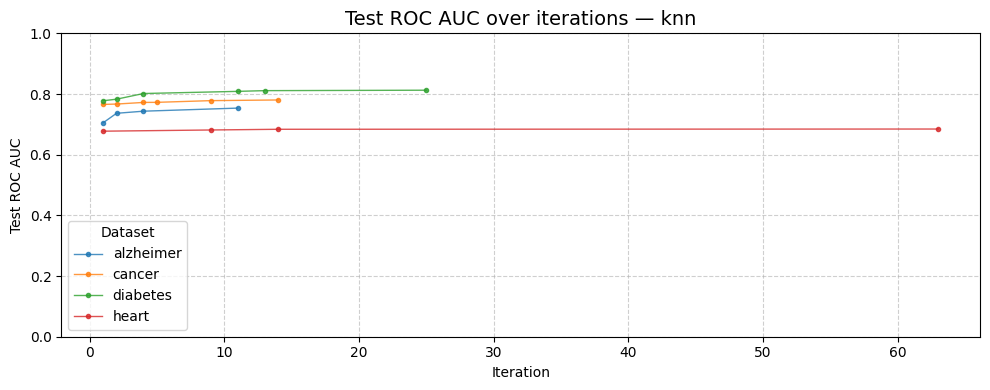

In [13]:
def get_increasing_points(iterations, scores):
    inc_iterations = []
    inc_scores = []
    prev_score = None
    for it, sc in zip(iterations, scores):
        if prev_score is None or sc > prev_score:
            inc_iterations.append(it)
            inc_scores.append(sc)
            prev_score = sc
    return inc_iterations, inc_scores

for model_name in models:
    plt.figure(figsize=(10, 4))
    subset = all_df[all_df["model"] == model_name]

    for dataset_name, group in subset.groupby("dataset"):
        group_sorted = group.sort_values("iteration")
        iterations = group_sorted["iteration"].values
        scores = group_sorted["test_roc_auc"].values

        # filtrujemy tylko rosnące punkty względem poprzedniego
        up_iterations, up_scores = get_increasing_points(iterations, scores)

        plt.plot(
            up_iterations,
            up_scores,
            marker='o',
            linestyle='-',
            alpha=0.8,
            label=dataset_name,
            markersize=3,
            linewidth=1
        )

    plt.title(f"Test ROC AUC over iterations — {model_name}", fontsize=14)
    plt.xlabel("Iteration")
    plt.ylabel("Test ROC AUC")
    plt.ylim(0, 1)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Dataset")
    plt.tight_layout()
    plt.show()


In [22]:
all_df[all_df["model"]=="Decision Tree"][["test_roc_auc", "iteration"]].tail()

,test_roc_auc,iteration
795,0.753584,96
796,0.500000,97
797,0.753584,98
798,0.500000,99
799,0.844729,100


In [17]:
all_df["model"].unique()

array(['XGBoost', 'Decision Tree', 'KNN'], dtype=object)

C:\Users\Kasia\AppData\Local\Temp\ipykernel_26648\189261685.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=models)


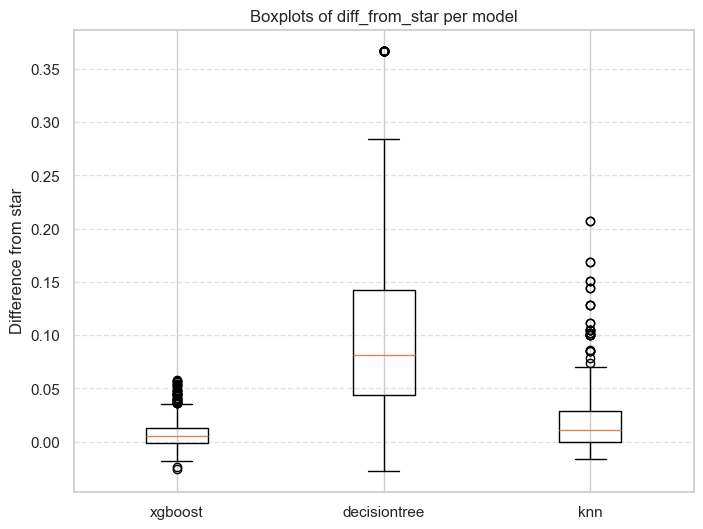

In [29]:
models = all_df['model'].unique()

# dane do boxplotów: dla każdego modelu bierzemy diff_from_star
data_to_plot = [all_df.loc[all_df['model'] == m, 'diff_from_star'] for m in models]

plt.figure(figsize=(8, 6))
plt.boxplot(data_to_plot, labels=models)
plt.ylabel("Difference from star")
plt.title("Boxplots of diff_from_star per model")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()